 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Kevin O'Hagan    <br>
Student Number : L00196770       <br>
Due Date       : May 12th 2026   <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



In [ ]:
TODO!


# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [1]:
# pip installs everything in the file, easier to list out there.
!pip install -r requirements.txt


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------- ---- 11.3/12.8 MB 86.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 79.4 MB/s  0:00:00


In [2]:
# Need to ensure to download the file to use it later on.
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


### Note: must have Tesseract setup on local machine.

## Imports

In [3]:
# imports
import os
import matplotlib.pyplot as plt
import spacy
import nltk
import io
import pymupdf
import re
import cv2
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

import pytesseract
from pytesseract import Output

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('punkt_tab')

# To run locally, update ath to your local tesseract executable file.
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
nlp = spacy.load("en_core_web_sm")

In [5]:
current_path = os.getcwd()
print(current_path)

C:\Users\User\Documents\ATUCourse\Artificial Intelligence for Vision and NLP\CA2\ca2-assignment-one-random-random-1


# Support Functions

In [7]:
## Setting config values to be used here
# Adding custom options for tesseract
# using the latest tesseract verion 5.0
tesseract_custom_config = r'--oem 1 --psm 4'  

In [30]:
## Regex patterns
import re

MONEY_RE = re.compile(r"""
    \b
    (?:€|EUR)?        # optional currency symbol/code
    \s*
    \d+               # whole number part
    [.,]
    \d{2}             # cents
    \b
""", re.IGNORECASE | re.VERBOSE)

DATE_RE = re.compile(r"""
    \b
    \d{1,2}           # day
    \s+
    (?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|
       May|Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|
       Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)
    \s+
    \d{4}             # year
    \b
""", re.IGNORECASE | re.VERBOSE)

KWH_RE = re.compile(r"""
    \b
    \d+(?:[.,]\d+)?   # number, optionally decimal
    \s*
    kWh
    \b
""", re.IGNORECASE | re.VERBOSE)

PERCENT_RE = re.compile(r"""
    \b
    \d+(?:[.,]\d+)?   # number, optionally decimal
    \s*
    %
""", re.VERBOSE)

PHONE_RE = re.compile(r"""
    \b
    \+?               # optional +
    \d
    [\d\s-]{7,}       # digits, spaces, or hyphens
    \d
    \b
""", re.VERBOSE)

ACCOUNT_RE = re.compile(r"""
    \b
    \d{6,12}          # 6 to 12 digits
    \b
""", re.VERBOSE)


In [2]:
# code here

## Helper to load/read in .pdf files
def convert_pdf_to_jpg(path, newfilename):
    doc = pymupdf.open(path)
    output_files = []
    
    # if the pdf ad multiple pages this for loop can be edited to accommodate
    for page_number, page in enumerate(doc, start=1):
        pix = page.get_pixmap(dpi=200)
        output_path = f"{newfilename}_page_{page_number}.jpg"
        pix.save(output_path)
        output_files.append(output_path)
    
    return output_files

## Helper to load/read in .jpg files

## Helper to grab all the text as string from image and return it
def get_img_text(img, config="--oem 3 --psm 11"):
    return pytesseract.image_to_string(img, config=config)

## Helper to put boxes around characters on the image and plot it
def show_boxes_around_chars(img):
    h, w, c = img.shape
    boxes = pytesseract.image_to_boxes(img)
    for b in boxes.splitlines():
        b = b.split(' ')
        img = cv2.rectangle(img, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 2) #OpenCV is in Blue, Green, Red format.
    
    plt.imshow(img)
    plt.show()

## Get the data from image as a dataframe and return it
def get_ocr_data(img, config="--oem 3 --psm 11"):
    data = pytesseract.image_to_data(img, config=config,output_type=Output.DATAFRAME)
    data = data.dropna(subset=["text"])
    data = data[data["text"].str.strip() != ""]
    return data

## Helper to get the overall average confidence score of valid conf values in the dataframe supplied
def get_mean_confidence(ocr_df):
    valid = ocr_df[ocr_df["conf"] > -1]
    if len(valid) == 0:
        return 0
    return valid["conf"].mean()

## Helper to rotate imported items

## Helper to scale??

## Helper to compare results of one set of text to another, both provided as params (use for the utitlity bills comparison)

# Helper to clean text
def get_clean_text(text):
    result = text
    # replace tabs with a single space
    result = result.replace("\t", " ")
    return result.strip()

# Helper to get the entities and noun chunks
def get_entities_with_noun_chunks(doc):
    noun_chunks = list(doc.noun_chunks)
    rows = []

    for entity in doc.ents:
        chunk_for_entity = ""

        for chunk in noun_chunks:
            if entity.start >= chunk.start and entity.end <= chunk.end:
                chunk_for_entity = chunk.text
                break

        rows.append({
            "named_entity": entity.text,
            "label": entity.label_,
            "noun_chunk": chunk_for_entity
        })

    return pd.DataFrame(rows)

# Specific helper for the utility bill, may need to move elswhere??
def extract_utility_bill_fields(text):
    return {
        "money_amounts": MONEY_RE.findall(text),
        "dates": DATE_RE.findall(text),
        "kwh_usage": KWH_RE.findall(text),
        "percentages": PERCENT_RE.findall(text),
        "phone_numbers": PHONE_RE.findall(text),
        "possible_account_numbers": ACCOUNT_RE.findall(text),
    }

# Create muliptle versions of the file provided using different techniques to allow for comparison
def create_image_versions(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gaussian = cv2.GaussianBlur(gray, (5, 5), 0)
    median = cv2.medianBlur(gray, 3)

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    adaptive_mean = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )
    adaptive_gaussian = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    return {
        "gray": gray,
        "gaussian_blur": gaussian,
        "median_blur": median,
        "otsu_binary": binary,
        "adaptive_mean": adaptive_mean,
        "adaptive_gaussian": adaptive_gaussian
    }

# NLP

## Sub Heading 1

original_rotated_rgb
Words found: 277
Mean confidence: 74.74986263176895
Sample text:
tral \\ " \ | % lal \i at ad - | F \ a4) } & : | ae iA dl Na Ad > Bord Gais E nergy =% a Account nymper: Your plan: Urban 24 Hout VariablePriceP!2° Contract end dare: 09 April 202 Meter num! MPRWN! DG Mcc
--------------------------------------------------------------------------------
gray
Words found: 308
Mean confidence: 73.23597224025973
Sample text:
. = 11) | | \G | 44 Yk t| an i] V1) + | : | " i Vi 1 Dal i \ \ 4) tii] \| Lt %| i | \! 114 | 7 \ \ \4 | ty i he \ | hit} 1 \\ \ 1}
--------------------------------------------------------------------------------
denoised
Words found: 268
Mean confidence: 79.34322538805971
Sample text:
\it 1 | eee. \G ie | \} iV : \\ » a fh | i Ee] 1 t | to) } \] \| ; | 1} i. 14 aa) 2 | ££ is} a) 4 ae 1th ib Bord Gais ¥. Energy Accoum nymper: Your plan: Urban 24 Hout
--------------------------------------------------------------------------------
threshold
Words found: 

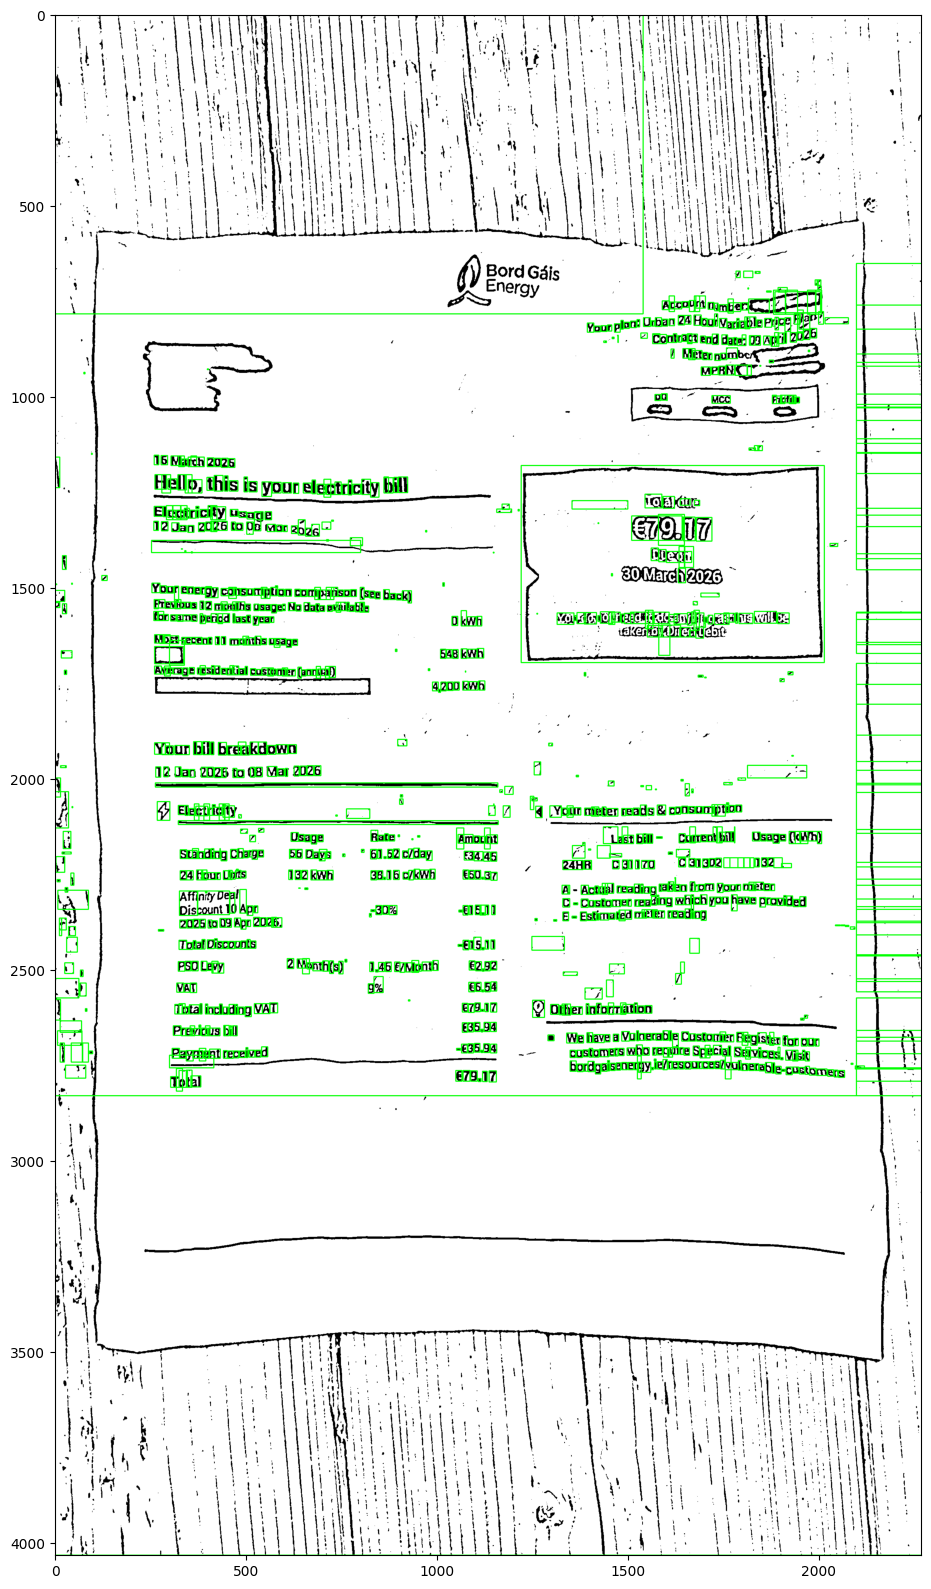

\it 1 | eee. \G ie | \} iV : \\ » a fh | i Ee] 1 t | to) } \] \| ; | 1} i. 14 aa) 2 | ££ is} a) 4 ae 1th ib Bord Gais ¥. Energy Accoum nymper: Your plan: Urban 24 Hout VariablePriceP/2° Contract end date: 09 April 202 Meter num MPRW: —- McC Profile ] J 16 March 2026 Hello, this is your electricity bill Total due Electricity usage 12 Jan 2026 to 08 Mar 2026 —— — 19: 17 Due on 30 March 2026 Your energy consumption comparison (see back) Previous 12 months usage: No data available for same period last year OkWh You do not need to do as th will be taken by [ bit Most recent 11 months usage 548 kwh Average residential customer (annual) 4,200 kWh Your bill breakdown 12 Jan 2026 to 08 Mar 2026 4 , Electricity 4 Your meter reads & consumption — ————_ Usage Rate Amount Last bill Current bill Usage (kWh) Standing Charge 56 Days 61.52 c/day €34.45 € 31302 132 24 hour Units 132 kWh 38.16 c/kWh €50.37 24HR c 31170 Affinity Deal A - Actual reading ‘aken from your meter Discount 10 Apr -30% -€15.11 C 

,image_version,words_found,mean_confidence,contains_amount_79_17,contains_kwh
0,original_rotated_rgb,277,74.749863,True,True
1,gray,308,73.235972,True,True
2,denoised,268,79.343225,True,True
3,threshold,483,57.878026,True,True


In [11]:
## code

# Setting global params for matplotlib
plt.rcParams['figure.figsize'] = (20, 20)

## Load up the image (eventually do it in some form of loop)
utility_bill_image_location = current_path + "\\data\\originals\\photographed\\utility_bill\\utility_bill_page_1.jpg"
utility_bill_1_img = cv2.imread(utility_bill_image_location)

## Create the different versions of the image to analyse
###########################################################
# since image is horiziontal, need to rotate to allow analysis of text to work
rotated_utility_bill_1_img = cv2.rotate(utility_bill_1_img,cv2.ROTATE_90_COUNTERCLOCKWISE)
# rgb the image from bgr
utility_bill_1_img_rgb = cv2.cvtColor(rotated_utility_bill_1_img, cv2.COLOR_BGR2RGB)
# improve the image to get better text to display
gray_utility_bill_1_img = cv2.cvtColor(rotated_utility_bill_1_img, cv2.COLOR_BGR2GRAY)
# denoise the image and use that for the threshold application
denoised_utility_bill_1_img = cv2.medianBlur(gray_utility_bill_1_img, 3)
# denoised_utility_bill_1_img = gray_utility_bill_1_img
# apply thresholds to improve image further
threshold_applied_utility_bill_1_img = cv2.adaptiveThreshold(
    denoised_utility_bill_1_img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    11
)

# plt.figure(figsize=(10, 12))
# plt.imshow(threshold_applied_utility_bill_1, cmap="gray")
# plt.axis("off")
# plt.show()

# show_boxes_around_chars(cv2.cvtColor(threshold_applied_utility_bill_1_img, cv2.COLOR_GRAY2BGR))
# utility_bill_text = get_img_text(threshold_applied_utility_bill_1_img, "--oem 3 --psm 11")

ocr_results = {}

ocr_results["original_rotated_rgb"] = get_ocr_data(rotated_utility_bill_1_img)
ocr_results["gray"] = get_ocr_data(gray_utility_bill_1_img)
ocr_results["denoised"] = get_ocr_data(denoised_utility_bill_1_img)
ocr_results["threshold"] = get_ocr_data(threshold_applied_utility_bill_1_img)

for name, df in ocr_results.items():
    print(name)
    print("Words found:", len(df))
    print("Mean confidence:", get_mean_confidence(df))
    print("Sample text:")
    print(" ".join(df["text"].astype(str).head(50)))
    print("-" * 80)

show_boxes_around_chars(cv2.cvtColor(threshold_applied_utility_bill_1_img, cv2.COLOR_GRAY2BGR))
## Setting best for use later.
best_utility_bill_version = "denoised" # "threshold"
best_utility_bill_ocr_df = ocr_results[best_utility_bill_version]
best_utility_bill_text = " ".join(best_utility_bill_ocr_df["text"].astype(str))

print(best_utility_bill_text[:1000])

ocr_summary = []

for name, df in ocr_results.items():
    text = " ".join(df["text"].astype(str))
    
    ocr_summary.append({
        "image_version": name,
        "words_found": len(df),
        "mean_confidence": get_mean_confidence(df),
        "contains_amount_79_17": "79.17" in text,
        "contains_kwh": "kWh" in text or "kwh" in text.lower()
    })

ocr_summary_df = pd.DataFrame(ocr_summary)
ocr_summary_df
##TODO Need to improve the finding of text above ^^^^
## Look into maybe cropping different sections of the page that are not being recognised like th bill amount €79


## PDF comparison to see what is available in a cleaner version of the same file and compare the two
## Try out the .extract_text() function instead of the swap to image and then extracting
# newfilename = "pdfConvertedUtilityBill1"
# utility_bill_pdf_location = current_path + "\\data\\originals\\scanned\\utility_bill\\utilitybill.pdf"
# convert_pdf_to_jpg(utility_bill_pdf_location, newfilename)
# new_converted_file_location = f"{current_path}\\{newfilename}.jpg"
# converted_utility_bill = cv2.imread(new_converted_file_location)
# utility_bill_1_img_rgb = cv2.cvtColor(converted_utility_bill, cv2.COLOR_BGR2RGB)

# initial_img_print_with_char_boxes(utility_bill_1_img_rgb)
# initial_img_text(utility_bill_1_img_rgb, tesseract_custom_config)

## Extract the text from the image (first 1 then a loop for all) and store it in an array or dictionary.

## Review the text manually against the image, draw the boxes, play with param values to find the sweet spot for the image

## Tokenise the text, perform stemming and lemmatisation
# nlp_utility_bill = nlp(utility_bill_text)
# # for token in nlp_utility_bill:
# #     print (token.text, token.pos_, end = " | ")
# col1 = "Named Entity"
# col2 = "Label"
# col3 = "Noun Chunk"

# sentance_noun_chunks = list(nlp_utility_bill.noun_chunks)

# # Header
# print(f"{col1:30} {col2:12} {col3:35}")
# print("-" * 80)
# for entity in nlp_utility_bill.ents:
#     chunk_for_entity = None
#     for chunk in sentance_noun_chunks:
#         # Check if the entity is in the noun chunk
#         if entity.start >= chunk.start and entity.end <= chunk.end:
#             chunk_for_entity = chunk.text
#             # breaking as will only be one instance
#             break

#     chunk_text = chunk_for_entity if chunk_for_entity is not None else ""
#     print(f"{entity.text:30} {entity.label_:12} {chunk_text:35}")

## Figure out the meaningful parts using TF-IDF or Bag of Words and NER. (Sentiment analysis could be good for book or acedemic paper)

## Categorise the sections. For the instructions and acedemic paper could try figure out the link between steps aswell as links to images

## Potentially remove the stop words, but be aware this could impact the Parts of Speech work later

## Consider grouping into Topics but not sure on this one and if it should live in this section or be included at all.

## Process and analyse the extracted text (tokenisation, stemming, lemmatisation, stopword removal)

- Use the "best_utility_bill_text" so can swap out its value if needed with less code change

In [8]:
## Clean
clean_utility_bill_text = get_clean_text(best_utility_bill_text)

# print("Original length:", len(best_utility_bill_text))
# print("Cleaned length:", len(clean_utility_bill_text))
# print(clean_utility_bill_text[:1000])

## Tokenise
nlp_utility_bill = nlp(clean_utility_bill_text)
token_df = pd.DataFrame([
    {
        "token": token.text,
        "lemma": token.lemma_,
        "pos": token.pos_,
        "is_stop": token.is_stop,
        "is_alpha": token.is_alpha,
        "is_digit": token.is_digit
    } for token in nlp_utility_bill
])

display(token_df.head(30))

# Remove stop words
## Keeping words only
filtered_token_df = token_df[
    (token_df["is_stop"] == False) &
    (token_df["is_alpha"] == True)
    ].copy()

filtered_token_df["token_lower"] = filtered_token_df["token"].str.lower()

# filtered_token_df.head(30)

## Keeping the numbers only, as its a utility bill need to know the figures as they are whats important!
analysis_token_df = token_df[
    (token_df["is_stop"] == False) &
    (token_df["token"].str.len() > 1)
].copy()

analysis_token_df["token_lower"] = analysis_token_df["token"].str.lower()

# analysis_token_df.head(30)

# Stemming
stemmer = PorterStemmer()

stem_df = filtered_token_df[["token", "token_lower"]].copy()
stem_df["stem"] = stem_df["token_lower"].apply(stemmer.stem)

display(stem_df.head(30))

# Lemmatisation
lemma_df = filtered_token_df[["token", "lemma", "pos"]].copy()
lemma_df["lemma_lower"] = lemma_df["lemma"].str.lower()

display(lemma_df.head(30))
## Order by counts
top_lemmas_df = (
    lemma_df["lemma_lower"]
    .value_counts()
    .reset_index()
)

top_lemmas_df.columns = ["lemma", "count"]
display(top_lemmas_df.head(20))

# Extrat entities and noun chunks
entities_df = get_entities_with_noun_chunks(nlp_utility_bill)
display(entities_df)
entity_counts = entities_df["label"].value_counts().reset_index()
entity_counts.columns = ["entity_label", "count"]
display(entity_counts)

# Pull out utility bill specific stuff
candidate_utility_fields = extract_utility_bill_fields(clean_utility_bill_text)

for key, value in candidate_utility_fields.items():
    print(key, ":", value)

# Top words
top_words_df = (
    lemma_df["lemma_lower"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_words_df.columns = ["term", "count"]
display(top_words_df)

# Setup for later Term Frequency Inverse Document Frequency by story
## Will only really be useful later when i add in all the other documents
document_texts = [
    clean_utility_bill_text
]

document_labels = [
    "utility_bill_page_1"
]

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30
)

tfidf_matrix = tfidf_vectorizer.fit_transform(document_texts)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=document_labels
)

display(tfidf_df)

,token,lemma,pos,is_stop,is_alpha,is_digit
0,\it,\it,PROPN,False,False,False
1,1,1,NUM,False,False,True
2,|,|,NOUN,False,False,False
3,eee,eee,NOUN,False,True,False
4,.,.,PUNCT,False,False,False
5,\G,\g,X,False,False,False
6,ie,ie,X,False,True,False
7,|,|,NOUN,False,False,False
8,\,\,NUM,False,False,False
9,},},PUNCT,False,False,False


,token,token_lower,stem
3,eee,eee,eee
6,ie,ie,ie
10,iV,iv,iv
15,fh,fh,fh
18,Ee,ee,ee
21,t,t,t
35,aa,aa,aa
46,ae,ae,ae
48,ib,ib,ib
49,Bord,bord,bord


,token,lemma,pos,lemma_lower
3,eee,eee,NOUN,eee
6,ie,ie,X,ie
10,iV,iv,X,iv
15,fh,fh,X,fh
18,Ee,Ee,PROPN,ee
21,t,t,NOUN,t
35,aa,aa,PROPN,aa
46,ae,ae,ADV,ae
48,ib,ib,NOUN,ib
49,Bord,Bord,PROPN,bord


,lemma,count
0,usage,5
1,kwh,5
2,bill,5
3,meter,4
4,total,4
5,customer,4
6,c,4
7,electricity,3
8,mar,2
9,apr,2


,named_entity,label,noun_chunk
0,\it 1,PRODUCT,\it 1 | eee
1,1,CARDINAL,
2,1,CARDINAL,
3,14,CARDINAL,
4,2 | ££,MONEY,
5,1th,ORDINAL,
6,Bord Gais,ORG,
7,Accoum,PERSON,Energy Accoum nymper
8,09 April,DATE,
9,Meter,PERSON,Meter num MPRW


,entity_label,count
0,DATE,14
1,CARDINAL,12
2,MONEY,8
3,ORG,4
4,LAW,2
5,PERSON,2
6,PRODUCT,1
7,ORDINAL,1
8,TIME,1
9,PERCENT,1


NameError: name 'MONEY_RE' is not defined

# Vision

## Sub Heading 1

In [ ]:
# code here...

## Preprocess the image/s using OpenCV. With the coke zero and bills, block out the outside useless information. Rotate and resize images as needed.

## Find the features in the image, use edge detection (could be good for rice image with instructions)

## Split out the parts of the image into areas and identify them. Similar to first step here or maybe move fully to here like removal of backround
## noise/useless parts

## Try to improve the focus of the words/the important parts of the document. The book has some blurry text with the scanning so could be useful here

In [ ]:
## Image Feature Detection: Utility Bill

In [ ]:
## Image preprocessin, run multiple processing techniques on the image

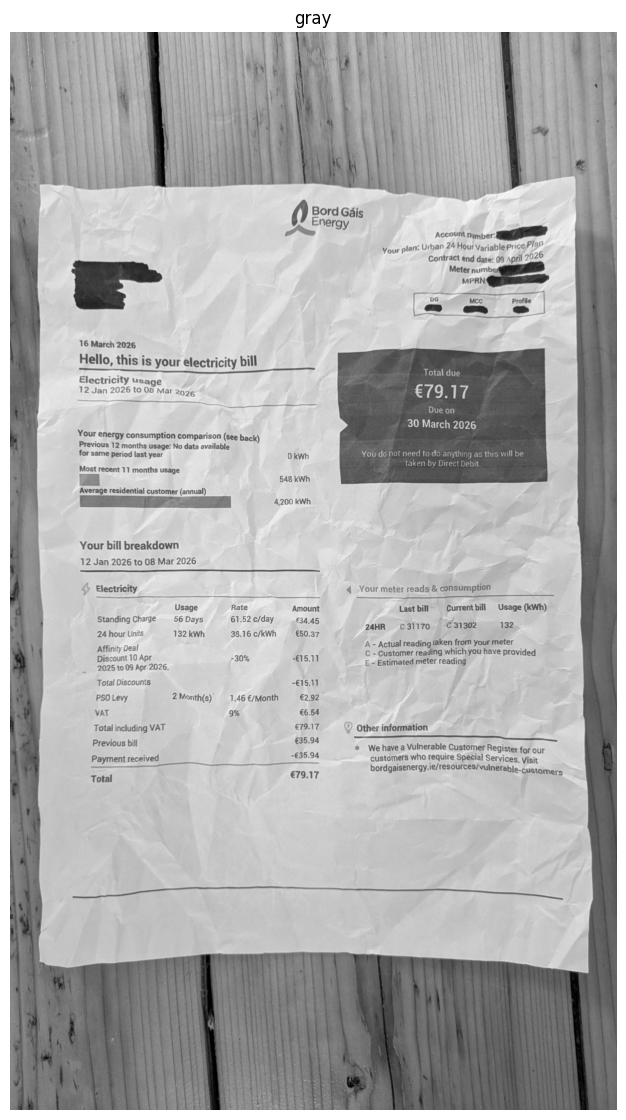

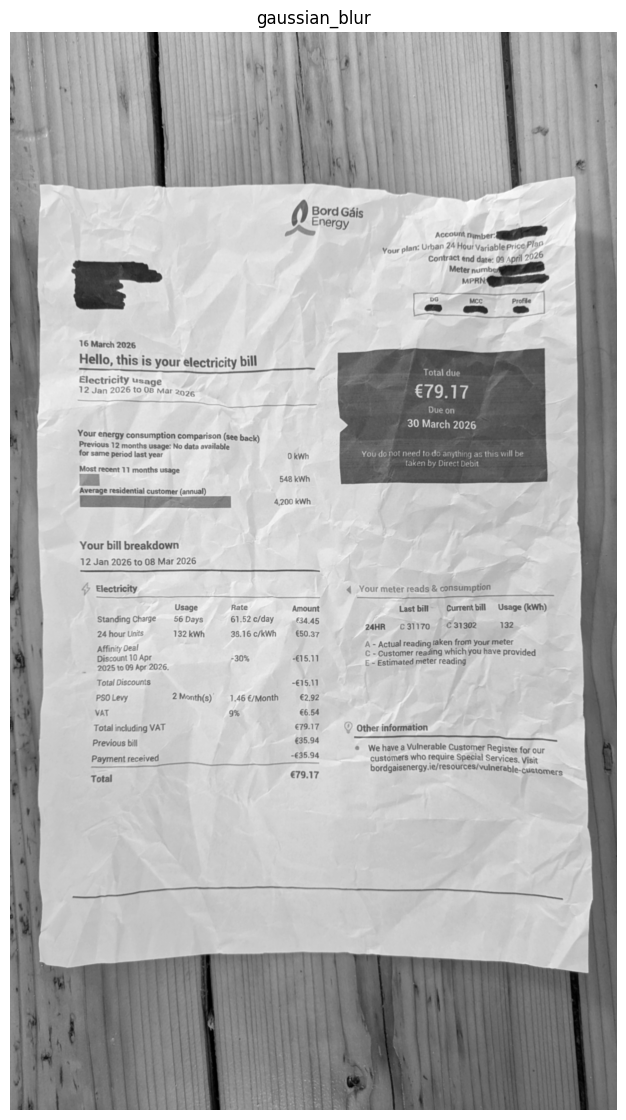

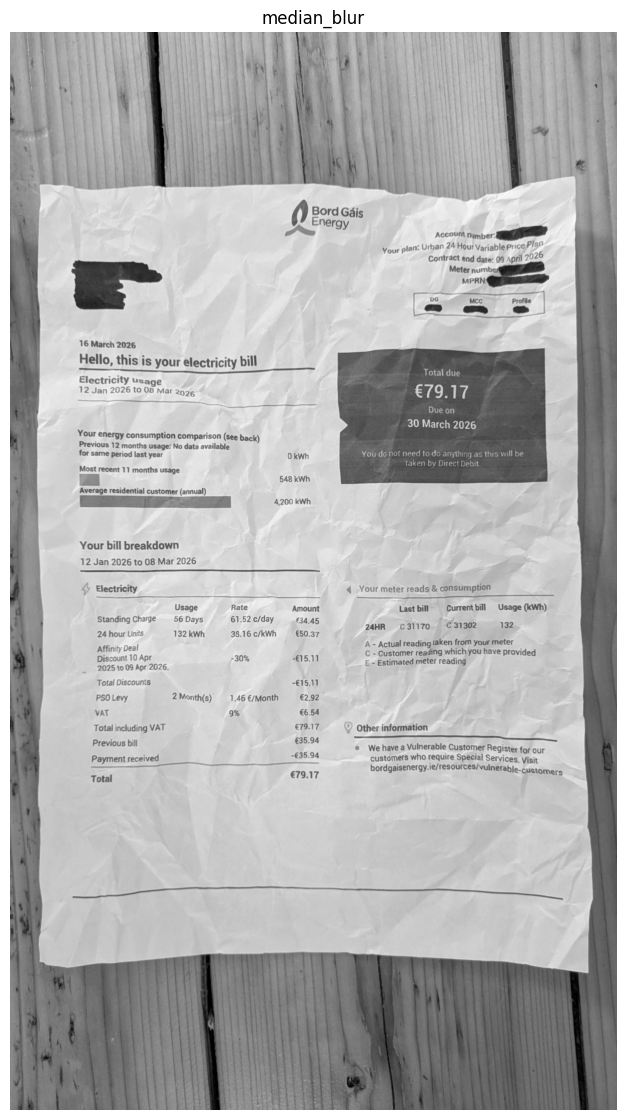

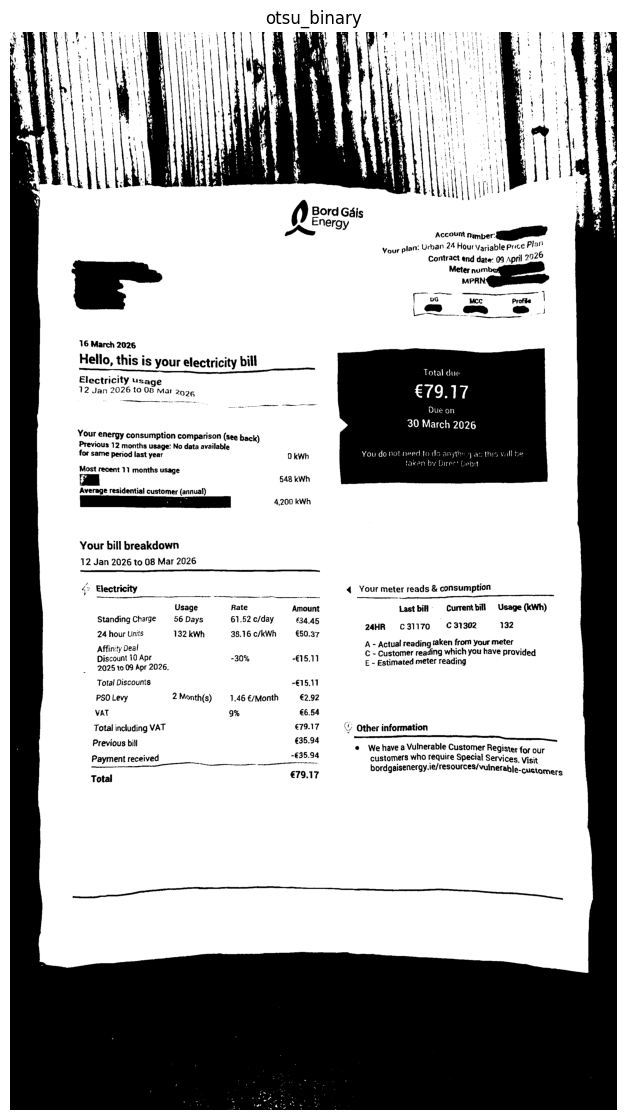

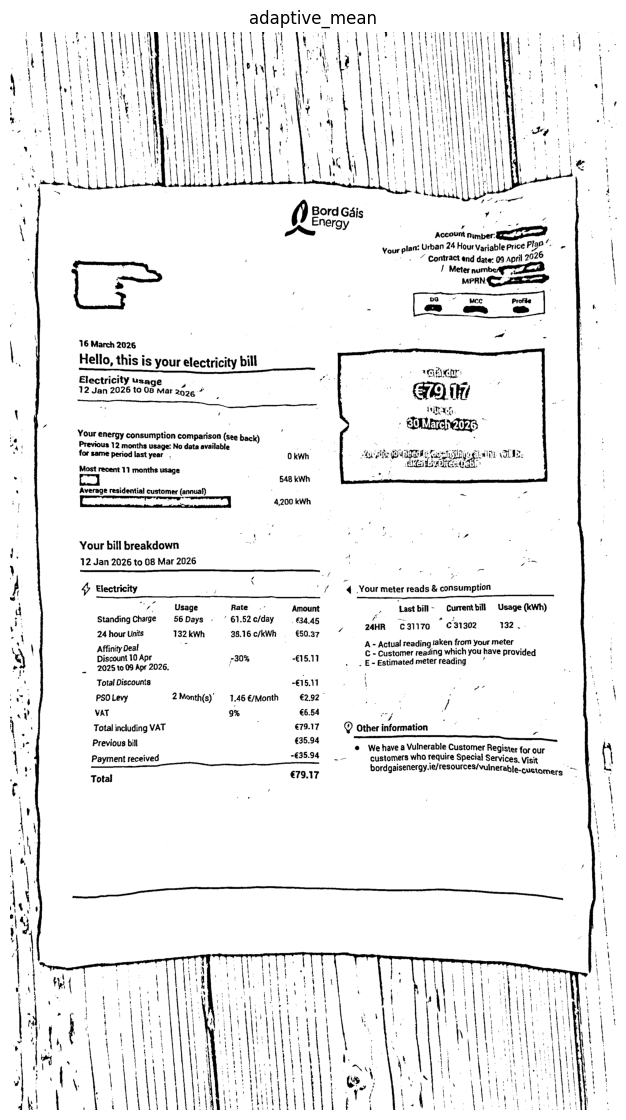

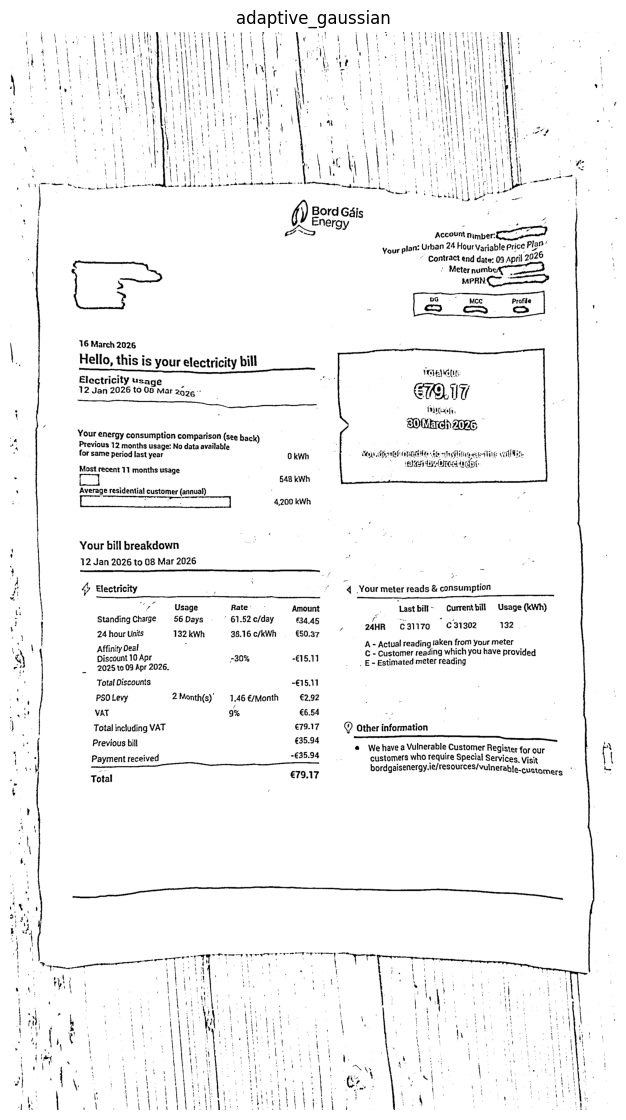

In [14]:
image_versions = create_image_versions(rotated_utility_bill_1_img)

for name, img in image_versions.items():
    plt.figure(figsize=(10, 14))
    plt.imshow(img, cmap="gray")
    plt.title(name)
    plt.axis("off")
    plt.show()

### Find edges uisng sobel and laplacian (try find which is better for image)

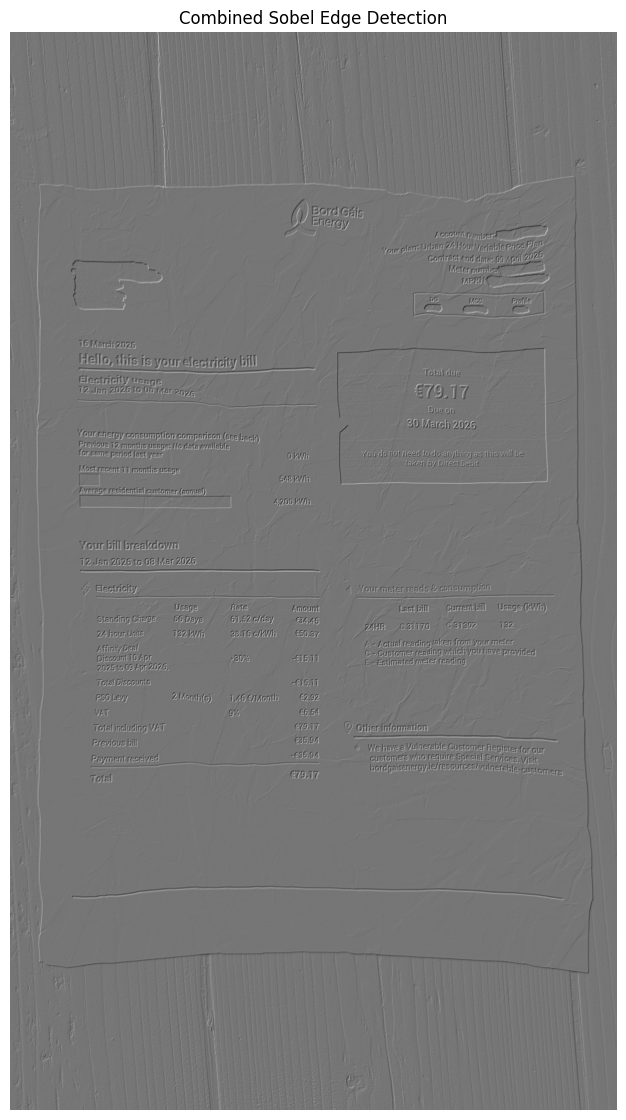

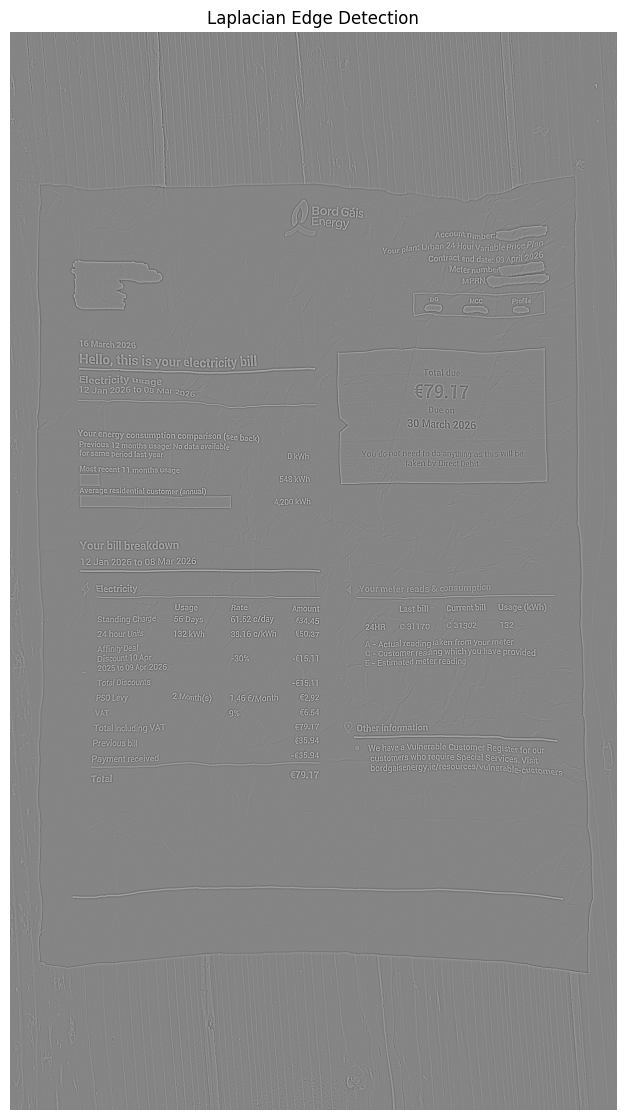

In [32]:
gray_doc = image_versions["gray"]

sobel_x = cv2.Sobel(gray_doc, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_doc, cv2.CV_64F, 0, 1, ksize=3)
laplacian = cv2.Laplacian(gray_doc, cv2.CV_64F, ksize=7)


sobel_combined = cv2.addWeighted(
    src1=sobel_x,
    alpha=0.5,
    src2=sobel_y,
    beta=0.5,
    gamma=0
)

plt.figure(figsize=(10, 14))
plt.imshow(sobel_combined, cmap="gray")
plt.title("Combined Sobel Edge Detection")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 14))
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian Edge Detection")
plt.axis("off")
plt.show()

## Try out the morphology from the tutorials 6a solution

- The detection is finding the sections really good.
- Need to look into setting the Region of Interest so that can narrow in on the file, that would mean the wood detail from the floor its sitting on will be removed so would not be highligthed in the results as an edge.

In [33]:
def create_text_region_mask(gray_img):
    binary = cv2.adaptiveThreshold(
        gray_img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        15
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))

    closed = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    return closed

def detect_regions_from_mask(mask, min_area=1000):
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    regions = []

    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h

        if area < min_area:
            continue

        regions.append({
            "region_id": len(regions),
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "area": area,
            "aspect_ratio": w / h if h else 0
        })

    return pd.DataFrame(regions).sort_values(["y", "x"]).reset_index(drop=True)

def draw_detected_regions(img_bgr, regions_df):
    output = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)

    for _, row in regions_df.iterrows():
        x, y, w, h = int(row["x"]), int(row["y"]), int(row["w"]), int(row["h"])
        region_id = int(row["region_id"])

        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(
            output,
            f"R{region_id}",
            (x, max(y - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    return output




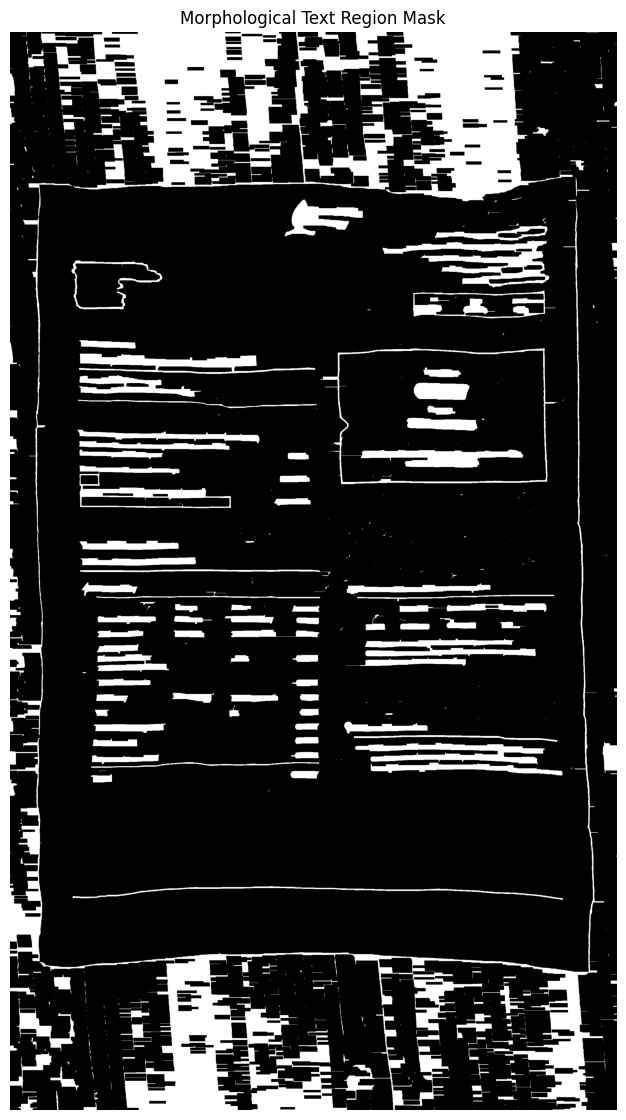

,region_id,x,y,w,h,area,aspect_ratio
0,109,66,0,2036,634,1290824,3.211356
1,108,2192,93,20,85,1700,0.235294
2,107,0,156,18,82,1476,0.219512
3,106,190,234,81,55,4455,1.472727
4,105,0,283,20,62,1240,0.322581
...,...,...,...,...,...,...,...
105,4,1726,3936,69,48,3312,1.437500
106,3,46,3958,53,19,1007,2.789474
107,2,1823,3976,73,20,1460,3.650000
108,1,32,3978,70,54,3780,1.296296


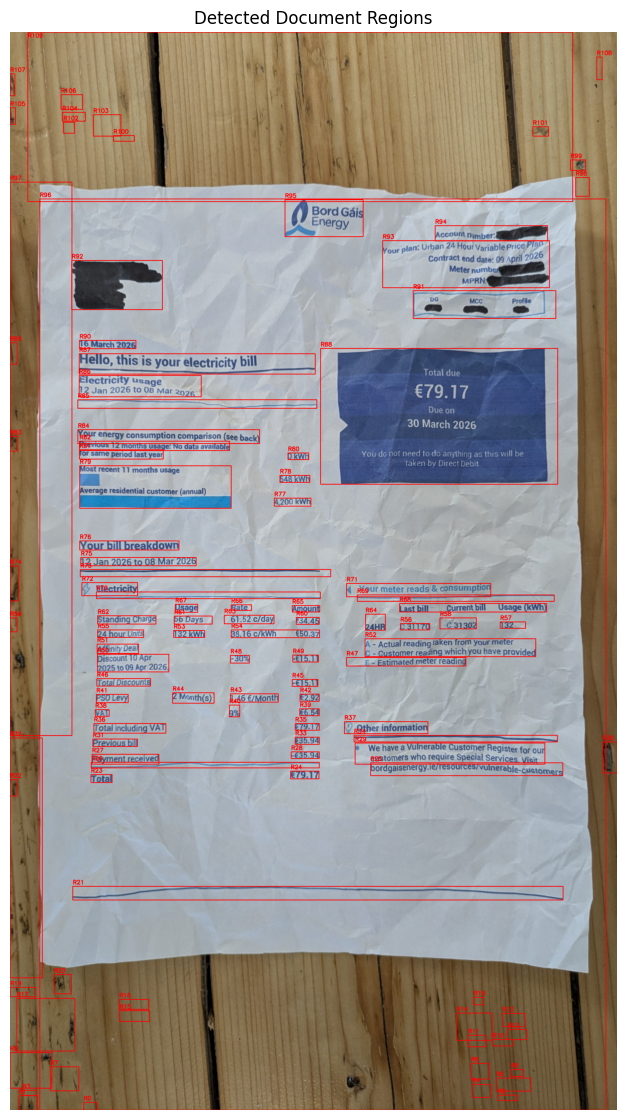

In [37]:

text_region_mask = create_text_region_mask(gray_doc)

plt.figure(figsize=(10, 14))
plt.imshow(text_region_mask, cmap="gray")
plt.title("Morphological Text Region Mask")
plt.axis("off")
plt.show()


regions_df = detect_regions_from_mask(text_region_mask)
display(regions_df)
annotated_regions_img = draw_detected_regions(rotated_utility_bill_1_img, regions_df)

plt.figure(figsize=(10, 14))
plt.imshow(annotated_regions_img)
plt.title("Detected Document Regions")
plt.axis("off")
plt.show()


# Multi-modal

## Sub Heading 1

In [ ]:
# code here

## Put together the image stuff with the text stuff to show an outcome/result for the document



# Final Output

In [ ]:
# code

In [ ]:
## Create the final output to compare the original image to the refined one. To compare the original read in text to the cleaned. And any
## of the analysis that was done.